# VGG11 Benchmark

In [1]:
model_name = "VGG11"

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
import numpy as np
import iree.compiler
import iree.runtime

import warnings
warnings.filterwarnings("ignore")

from timeit import timeit as ti
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def compile_str(mlir):
    return iree.runtime.load_vm_flatbuffer(
        iree.compiler.compile_str(
            mlir, input_type="tosa", target_backends=["llvm-cpu"],
            extra_args=[
                "--iree-llvmcpu-target-cpu-features=host",
                "--iree-stream-partitioning-favor=max-concurrency",
                "--iree-flow-zero-fill-empty-tensors",
                "--iree-llvmcpu-fail-on-out-of-bounds-stack-allocation=0",
                "--iree-opt-const-eval",
                "--iree-opt-const-expr-hoisting",
                "--iree-opt-numeric-precision-reduction",
                "--iree-opt-strip-assertions"
            ]
        ),
        backend="llvm-cpu"
    )

def compile_file(filename):
    with open(filename) as f:
        return compile_str(f.read())
    
def get_dataframe(forward, backward, item):
    return pd.concat([
        pd.DataFrame({
            "time": forward,
            "pass": "Forward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": backward,
            "pass": "Backward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": forward + backward,
            "pass": "Full",
            "item": item
        }, index=[0]),
    ])

def timeit(stmt, n=100):
    return ti(stmt, globals=globals(), number=n) * 1000 / n

## Prepare

In [2]:
model = tf.function(tf.saved_model.load("model").signatures["serving_default"])

recompute, storeall = [
    compile_file(x) for x in ["../recompute.mlir", "../storeall.mlir"]
]

2023-07-14 17:38:37.552454: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


## Experimental

In [3]:
image = tf.random.normal((1, 3, 224, 224))

with tf.GradientTape(persistent=True) as tape:
    tape.watch(image)
    output = list(model(image).values()).pop()
    
grad = tf.random.normal((1, 1000))

image_np = image.numpy()
grad_np = grad.numpy()

df = pd.DataFrame()

### TensorFlow (Baseline)

In [4]:
baseline_f = timeit("model(image)")
baseline_b = timeit("tape.gradient(output, image, grad)")
df = pd.concat([df, get_dataframe(baseline_f, baseline_b, "TensorFlow")])

### Nabla without Optim

In [5]:
f = timeit("recompute.forward(image_np)")
b = timeit("recompute.dforward(grad_np)")
df = pd.concat([df, get_dataframe(f, b, "Nabla")])

### Nabla with Optim

In [6]:
f = timeit("storeall.forward(image_np)")
b = timeit("storeall.dforward(grad_np)")
df = pd.concat([df, get_dataframe(f, b, "Nabla Optim")])

## Result

In [7]:
df.to_csv(f"{model_name}-time.csv")
df.style.hide(axis="index")

time,pass,item
57.945823,Forward,TensorFlow
329.837448,Backward,TensorFlow
387.783272,Full,TensorFlow
55.152797,Forward,Nabla
76.789227,Backward,Nabla
131.942024,Full,Nabla
71.793726,Forward,Nabla Optim
18.877289,Backward,Nabla Optim
90.671015,Full,Nabla Optim


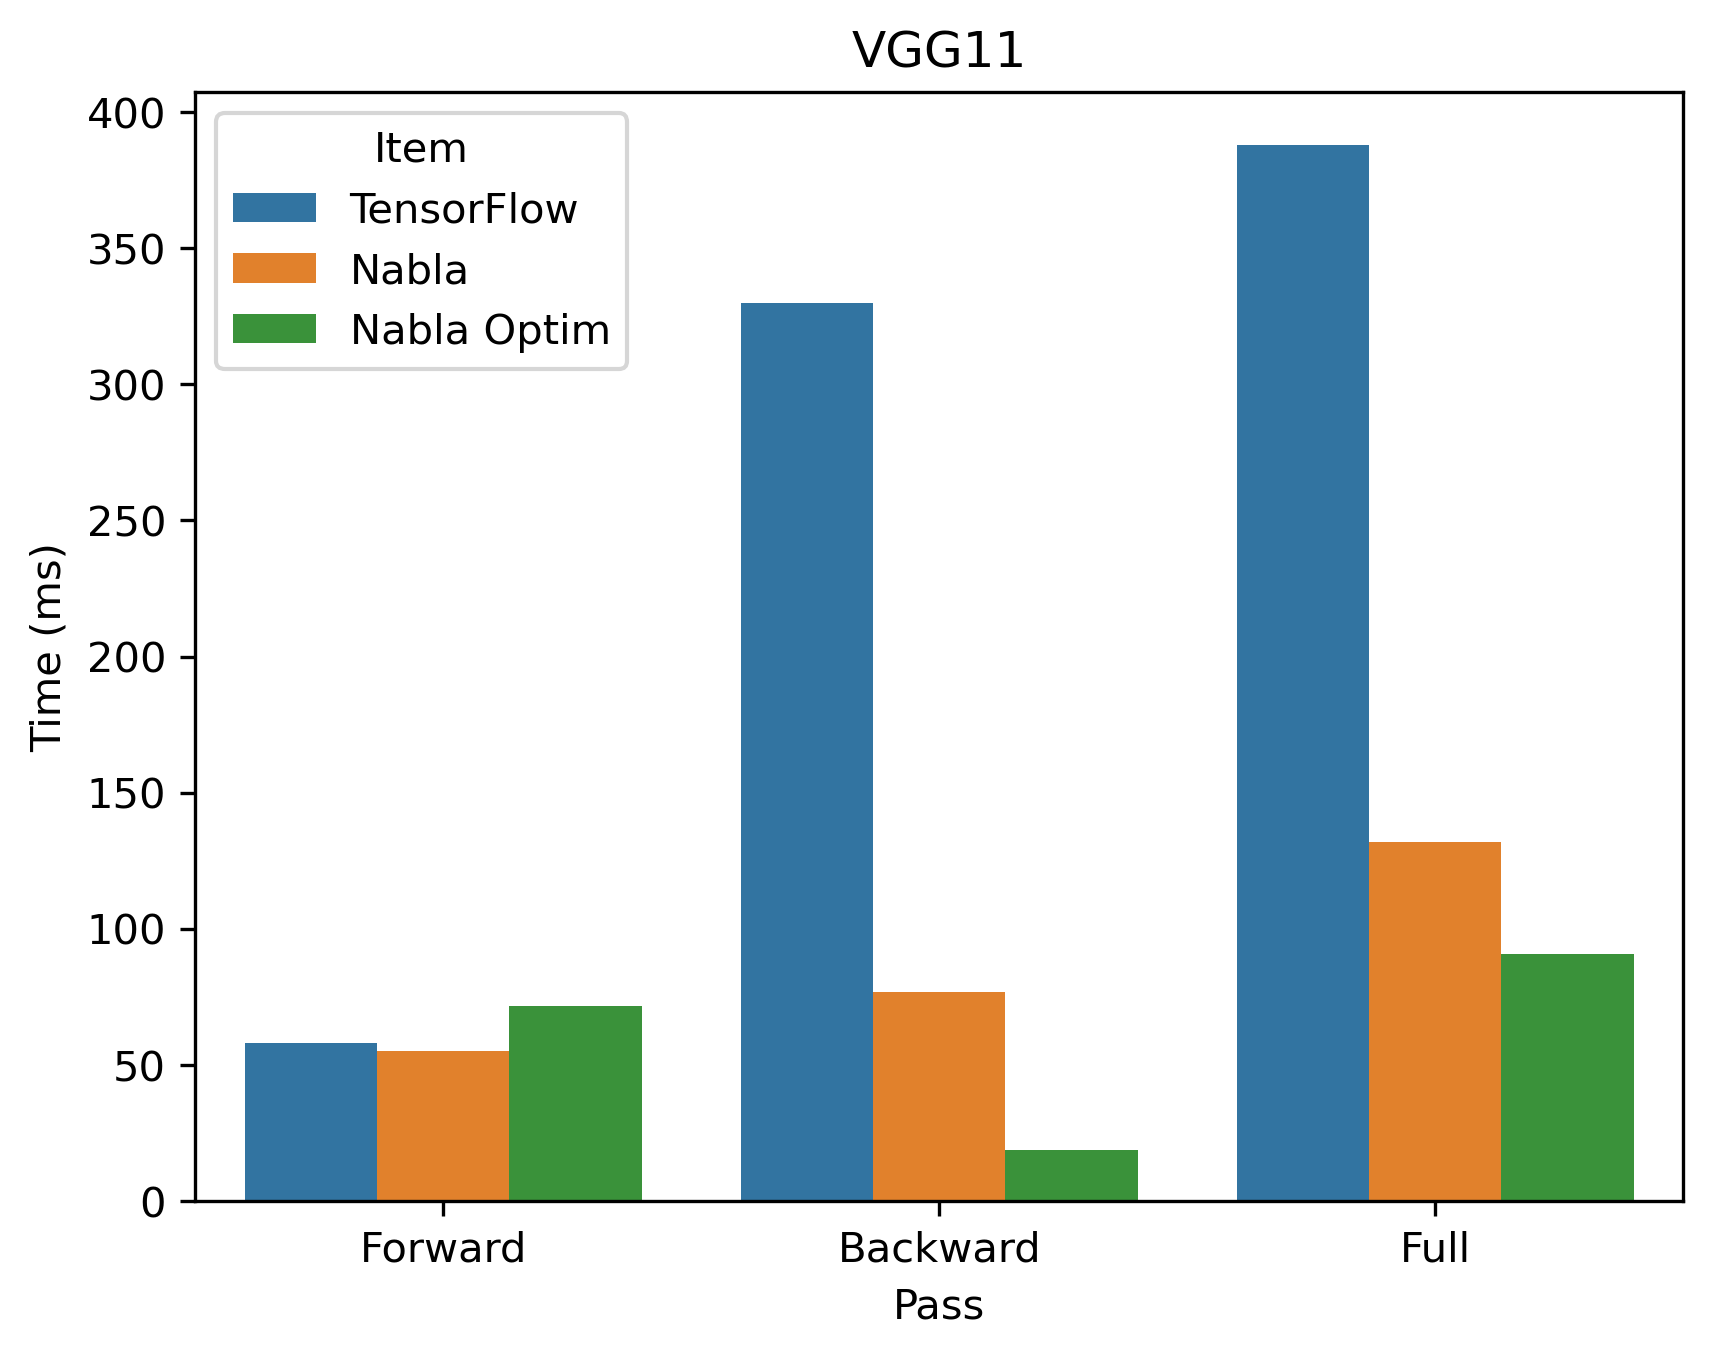

In [8]:
plt.rcParams["figure.dpi"] = 300

sns.barplot(df, x="pass", y="time", hue="item")
plt.xlabel("Pass")
plt.ylabel("Time (ms)")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-time.png")

In [9]:
forward = df[df["pass"] == "Forward"]
forward["acceleration"] = baseline_f / forward["time"]
forward

,time,pass,item,acceleration
0,57.945823,Forward,TensorFlow,1.000000
0,55.152797,Forward,Nabla,1.050642
0,71.793726,Forward,Nabla Optim,0.807115


In [10]:
backward = df[df["pass"] == "Backward"]
backward["acceleration"] = baseline_b / backward["time"]
backward

,time,pass,item,acceleration
0,329.837448,Backward,TensorFlow,1.000000
0,76.789227,Backward,Nabla,4.295361
0,18.877289,Backward,Nabla Optim,17.472713


In [11]:
full = df[df["pass"] == "Full"]
full["acceleration"] = (baseline_b + baseline_f) / full["time"]
full

,time,pass,item,acceleration
0,387.783272,Full,TensorFlow,1.000000
0,131.942024,Full,Nabla,2.939043
0,90.671015,Full,Nabla Optim,4.276816


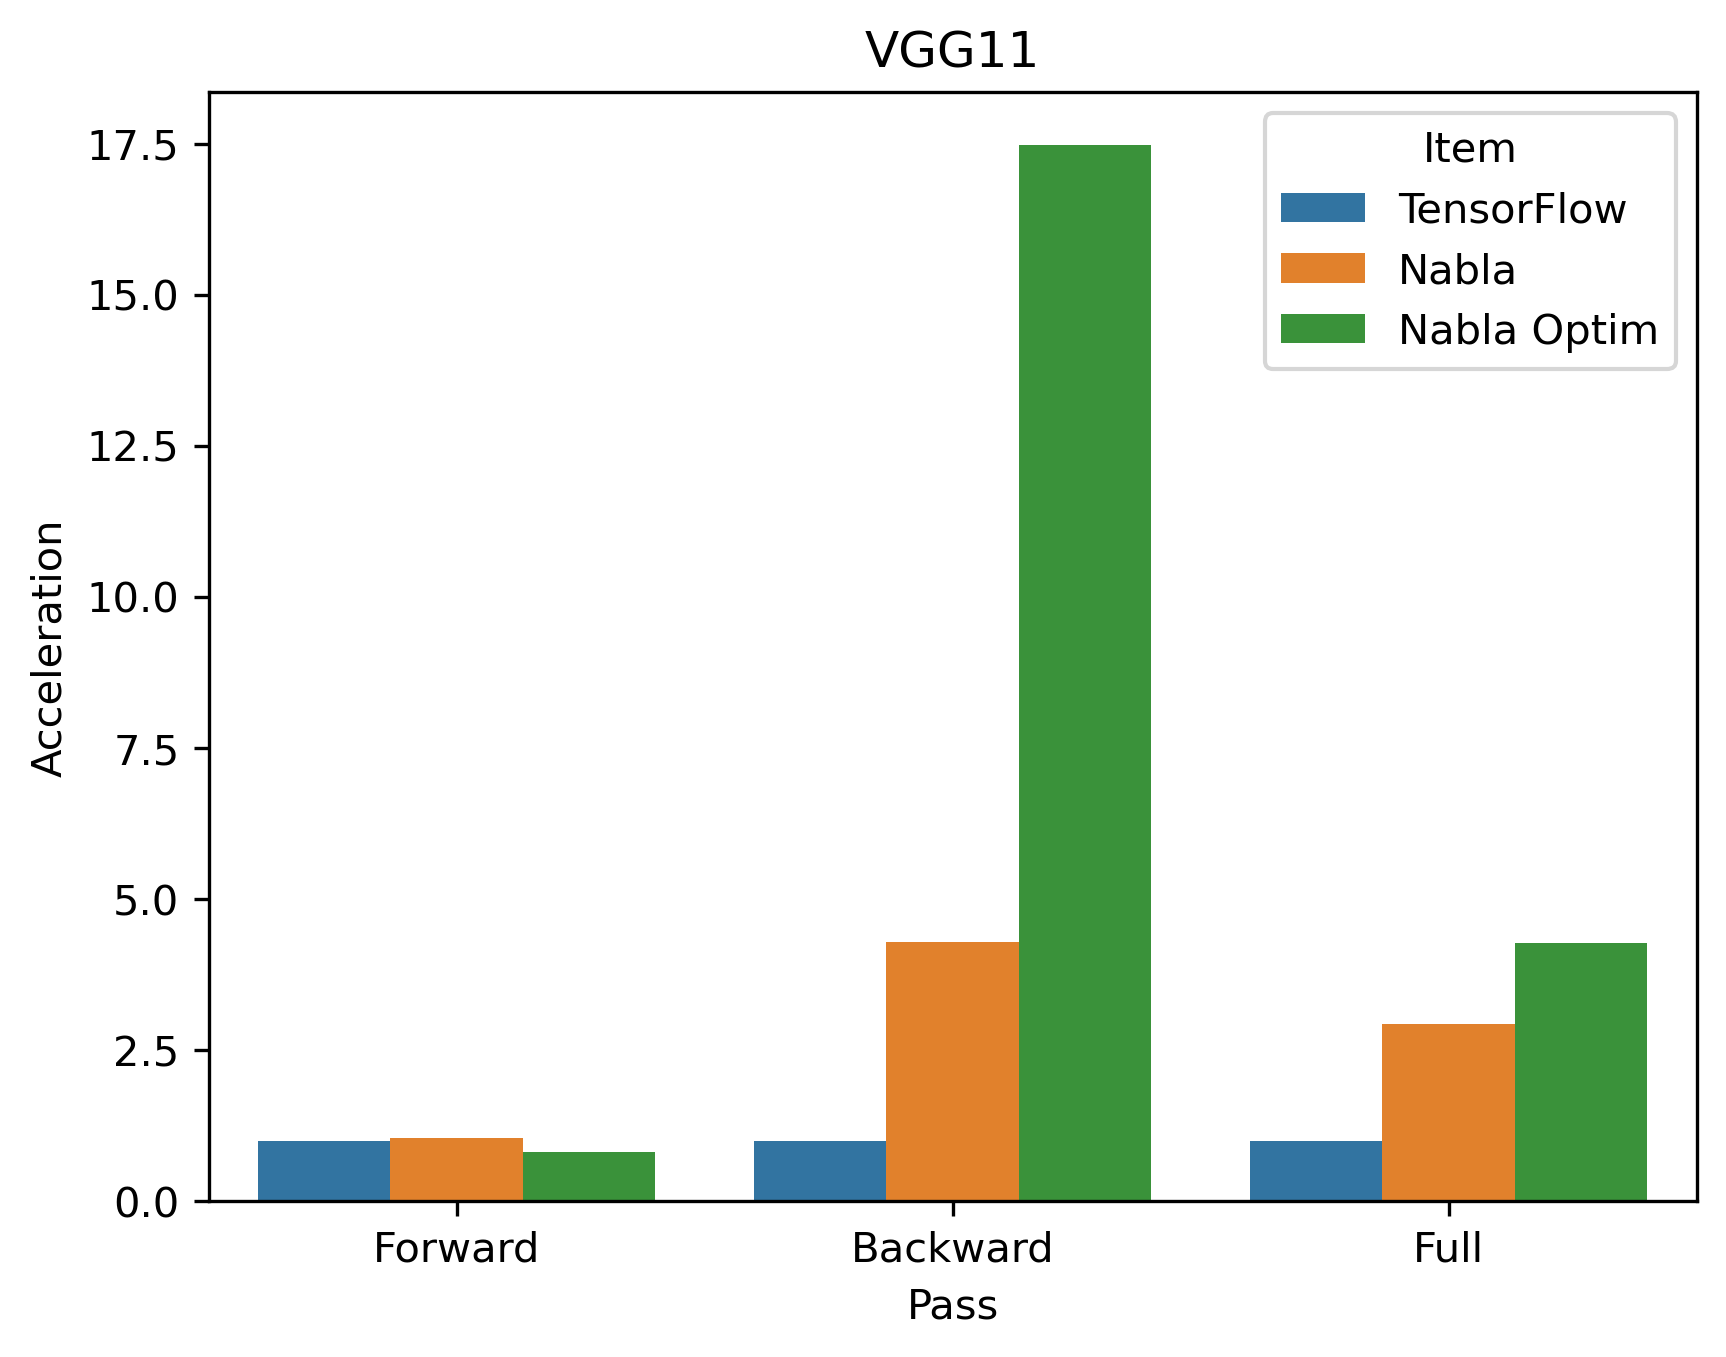

In [12]:
df = pd.concat([forward, backward, full])
df.to_csv(f"{model_name}-acceleration.csv")

sns.barplot(df, x="pass", y="acceleration", hue="item")
plt.xlabel("Pass")
plt.ylabel("Acceleration")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-acceleration.png")